# Global plots — ICON *LessOzone* experiment

Difference maps (our simulation − slab control) on the native ICON triangular
grid, plus a global-mean timeseries.

**Plots produced here**
1. Global-mean timeseries of 2 m temperature (`tas`) — control vs. simulation
2. Surface downwelling shortwave radiation (`rsds`) — difference map
3. (optional) 2 m temperature (`tas`) — difference map

All temporal means are taken over a **selectable year window** (default: last 5
years, where the forcing is strongest). The significance hatching uses a t-test
drawn from that *same* window, so it never borrows power from the full run.


In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
import cartopy.crs as ccrs
from scipy import stats

# Larger fonts everywhere (default labels were too small)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.dpi": 110,
})

## Load & prepare data

In [2]:


data_slabctr = xr.open_dataset(f"slabctr_2D_2000-2035.nc")        # slab control run
data         = xr.open_dataset(f"LessOzone_Real_2D_2000-2035.nc")  # our simulation
grid         = xr.open_dataset(f"icon_grid_G.nc")                  # triangular grid (for maps)


def to_datetime(ds):
    """Convert the YYYYMMDD float time axis into a proper datetime index."""
    strs = [str(int(d)) for d in ds["time"].values]
    iso  = [f"{s[:4]}-{s[4:6]}-{s[6:]}" for s in strs]
    return ds.assign_coords(time=pd.to_datetime(iso))


data_slabctr = to_datetime(data_slabctr)
data         = to_datetime(data)

# The control run carries an extra first month (Jan 2000) the simulation lacks.
data_slabctr = data_slabctr.isel(time=slice(1, None))

## Year window for temporal means

Set `MODE` once. Everything downstream (means *and* t-tests) respects it.

| MODE | Period averaged | Use |
|------|-----------------|-----|
| `"last5"`  | last `N_YEARS` years  | strongest forcing — **default** |
| `"first5"` | first `N_YEARS` years | weak/early forcing — contrast |
| `"all"`    | whole run             | full-period reference |

For a *first-5-vs-last-5* figure: render with `"first5"`, then `"last5"`, and
place the two side by side.

In [3]:
MODE    = "last5"      # "last5" | "first5" | "all"
N_YEARS = 5

years = np.unique(data["time"].dt.year.values)
if MODE == "last5":
    sel_years = years[-N_YEARS:]
elif MODE == "first5":
    sel_years = years[:N_YEARS]
elif MODE == "all":
    sel_years = years
else:
    raise ValueError(f"Unknown MODE: {MODE!r}")

period = f"{int(sel_years.min())}-{int(sel_years.max())}"
print(f"MODE={MODE!r} -> averaging {len(sel_years)} years ({period})")


def in_window(ds):
    """Restrict a dataset to the selected years."""
    return ds.sel(time=ds["time"].dt.year.isin(sel_years))


data_win    = in_window(data)
slabctr_win = in_window(data_slabctr)

MODE='last5' -> averaging 5 years (2031-2035)


## Map helper (built once)

In [4]:
# Build the ICON triangulation once and reuse it for every map.
vlon = np.rad2deg(grid["vlon"].values)
vlat = np.rad2deg(grid["vlat"].values)
triangles = grid["vertex_of_cell"].values.T - 1          # (ncells, 3), 0-based

# Mask triangles that wrap across the antimeridian (they'd smear across the map).
x = vlon[triangles]
wrap = (np.abs(x[:, 0] - x[:, 1]) > 180) | \
       (np.abs(x[:, 1] - x[:, 2]) > 180) | \
       (np.abs(x[:, 0] - x[:, 2]) > 180)

triang = mtri.Triangulation(vlon, vlat, triangles, mask=wrap)


def diff_map(values, *, title, cbar_label, cmap, vmax=None,
             not_significant=None, savename=None):
    """Plot one difference field on the ICON grid, optionally hatching
    non-significant cells. `vmax` fixes a symmetric diverging scale; if None it
    is taken from the data."""
    if vmax is None:
        vmax = float(np.nanmax(np.abs(values)))
    # TwoSlopeNorm needs vmin < 0 < vmax; guard one-sided / all-zero fields.
    if not np.isfinite(vmax) or vmax == 0:
        norm = None
    else:
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig = plt.figure(figsize=(13, 6.5))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.coastlines(resolution="110m", linewidth=0.8, color="black")
    ax.set_title(title, pad=12)

    tc = ax.tripcolor(triang, values, norm=norm, cmap=cmap,
                      transform=ccrs.PlateCarree(), shading="flat",
                      rasterized=True)

    if not_significant is not None:
        ns = mtri.Triangulation(vlon, vlat, triangles)
        mask = wrap.copy()
        mask[~not_significant] = True          # show ONLY non-significant cells
        ns.set_mask(mask)
        ax.tripcolor(ns, np.zeros(len(values)), cmap="Greys",
                     vmin=0, vmax=1, alpha=0.55,
                     transform=ccrs.PlateCarree(), shading="flat",
                     rasterized=True)

    cb = fig.colorbar(tc, ax=ax, orientation="horizontal",
                      pad=0.05, aspect=40, shrink=0.75)
    cb.set_label(cbar_label)

    fig.tight_layout()
    if savename:
        fig.savefig(savename, dpi=300, bbox_inches="tight")
        print("saved", savename)
    plt.show()


def ttest_month(da_run, da_ctrl, month):
    """Two-sample t-test for one calendar month over the windowed years.
    Returns a boolean 'not significant at 5%' field."""
    r = da_run.sel(time=da_run.time.dt.month == month).values
    c = da_ctrl.sel(time=da_ctrl.time.dt.month == month).values
    _, p = stats.ttest_ind(r, c, axis=0)
    print(f"  t-test: {r.shape[0]} vs {c.shape[0]} years")
    return p >= 0.05

## Plot 1 — Global-mean 2 m temperature timeseries

Global mean over all cells, monthly resolution, both runs on one axis. (Uses the
full record, not the year window — a timeseries should show the whole evolution.)

issue here


## Plot 2 — Surface shortwave radiation difference map

Monthly-group mean over the year window, simulation − control. Set `MONTH`
below.

  t-test: 4 vs 4 years
saved map_rsds_August_2031-2035.png


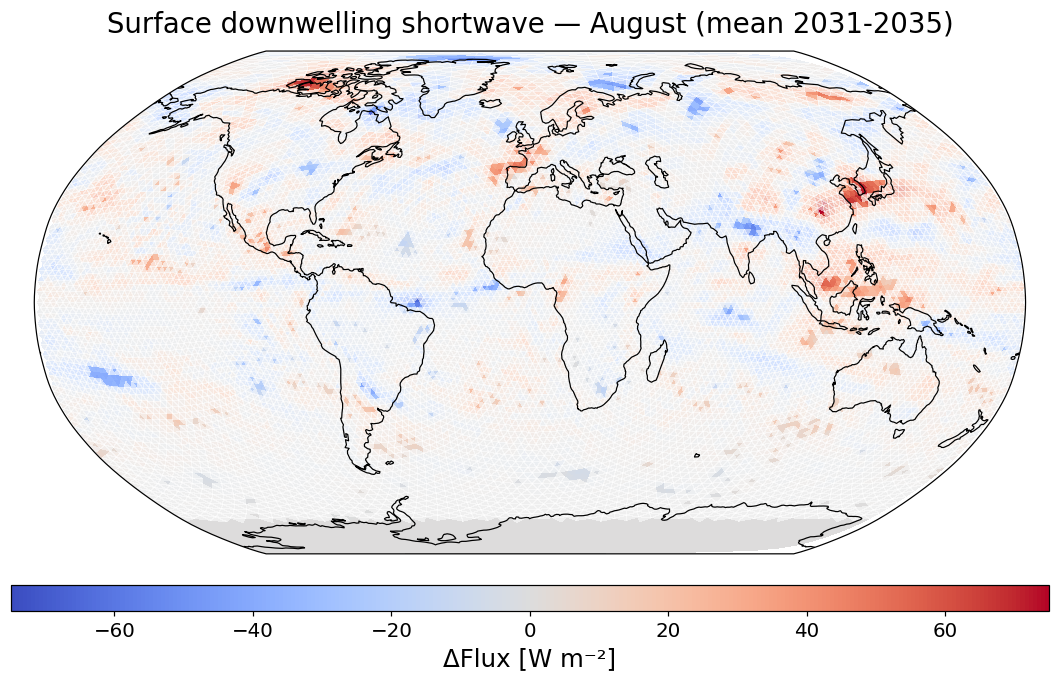

In [6]:
VAR   = "rsds"
MONTH = 8        # 1 = Jan … 12 = Dec
MONTHS = ["January", "February", "March", "April", "May", "June",
          "July", "August", "September", "October", "November", "December"]

sim_m  = in_window(data)[VAR].sel(time=data_win.time.dt.month == MONTH).mean("time")
ctrl_m = slabctr_win[VAR].sel(time=slabctr_win.time.dt.month == MONTH).mean("time")
values = (sim_m - ctrl_m).values

ns = ttest_month(data_win[VAR], slabctr_win[VAR], MONTH)

diff_map(
    values,
    title=f"Surface downwelling shortwave — {MONTHS[MONTH-1]} (mean {period})",
    cbar_label="ΔFlux [W m⁻²]",
    cmap="coolwarm",
    not_significant=ns,
    savename=f"map_rsds_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 3 (optional) — 2 m temperature difference map

Same routine, useful to place next to the radiation map.

  t-test: 4 vs 4 years
saved map_tas_August_2031-2035.png


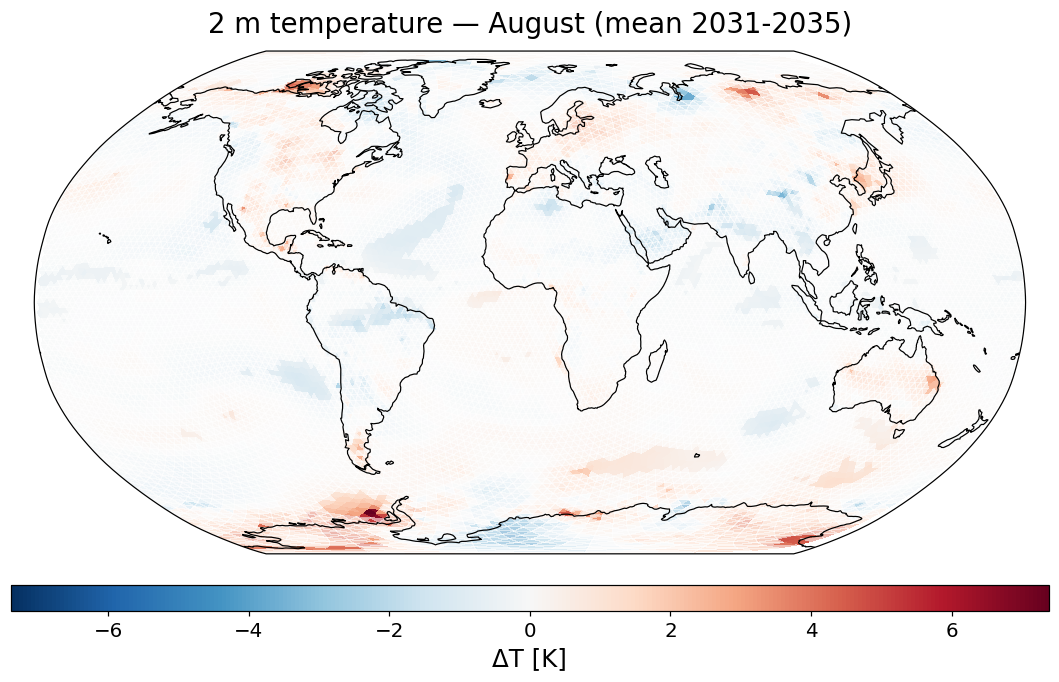

In [7]:
VAR   = "tas"
MONTH = 8

sim_m  = data_win[VAR].sel(time=data_win.time.dt.month == MONTH).mean("time")
ctrl_m = slabctr_win[VAR].sel(time=slabctr_win.time.dt.month == MONTH).mean("time")
values = (sim_m - ctrl_m).values

ns = ttest_month(data_win[VAR], slabctr_win[VAR], MONTH)

diff_map(
    values,
    title=f"2 m temperature — {MONTHS[MONTH-1]} (mean {period})",
    cbar_label="ΔT [K]",
    cmap="RdBu_r",
    not_significant=ns,
    savename=f"map_tas_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 4 — Precipitation difference map

ITCZ / storm-track shifts. Brown–blue–green diverging scale (dry↔wet).

  t-test: 4 vs 4 years
saved map_pr_August_2031-2035.png


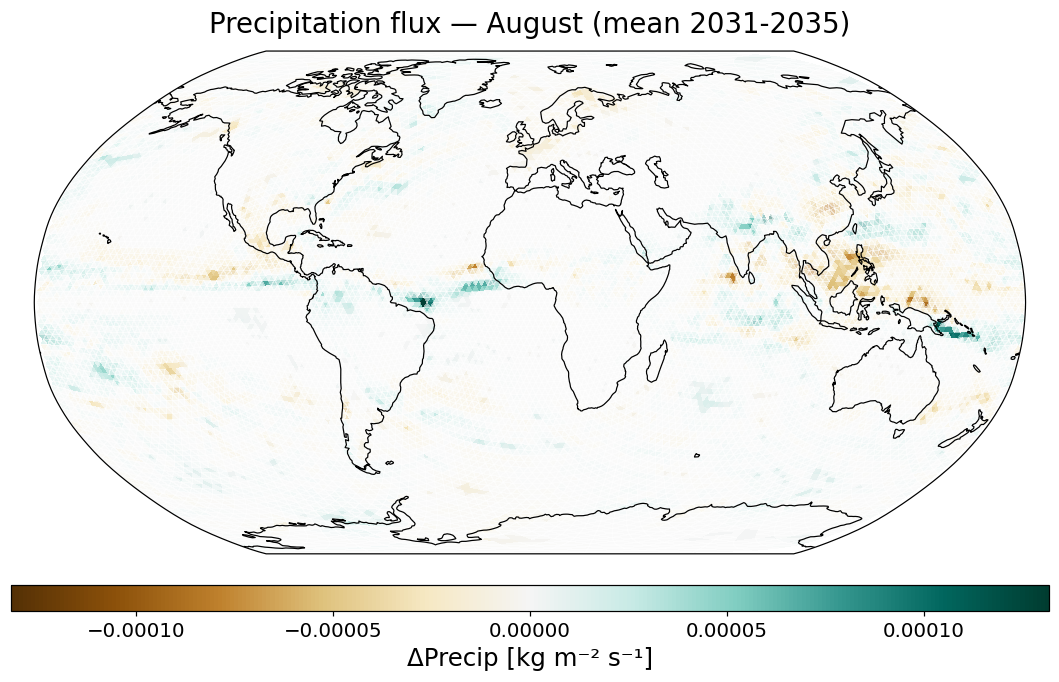

In [8]:
VAR   = "pr"
MONTH = 8        # 1 = Jan … 12 = Dec

sim_m  = data_win[VAR].sel(time=data_win.time.dt.month == MONTH).mean("time")
ctrl_m = slabctr_win[VAR].sel(time=slabctr_win.time.dt.month == MONTH).mean("time")
values = (sim_m - ctrl_m).values

ns = ttest_month(data_win[VAR], slabctr_win[VAR], MONTH)

diff_map(
    values,
    title=f"Precipitation flux — {MONTHS[MONTH-1]} (mean {period})",
    cbar_label="ΔPrecip [kg m⁻² s⁻¹]",
    cmap="BrBG",
    not_significant=ns,
    savename=f"map_pr_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 5 — Total cloud cover difference map

Cloud response; pairs with the shortwave map.

  t-test: 4 vs 4 years
saved map_clt_August_2031-2035.png


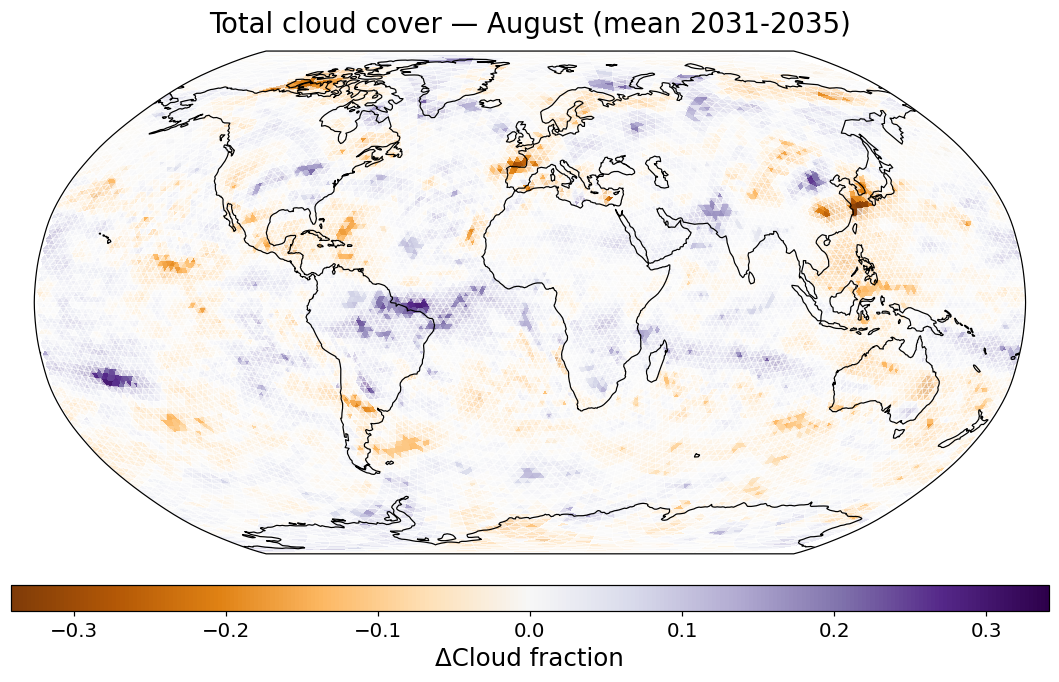

In [9]:
VAR   = "clt"
MONTH = 8        # 1 = Jan … 12 = Dec

sim_m  = data_win[VAR].sel(time=data_win.time.dt.month == MONTH).mean("time")
ctrl_m = slabctr_win[VAR].sel(time=slabctr_win.time.dt.month == MONTH).mean("time")
values = (sim_m - ctrl_m).values

ns = ttest_month(data_win[VAR], slabctr_win[VAR], MONTH)

diff_map(
    values,
    title=f"Total cloud cover — {MONTHS[MONTH-1]} (mean {period})",
    cbar_label="ΔCloud fraction",
    cmap="PuOr",
    not_significant=ns,
    savename=f"map_clt_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 6 — 10 m wind speed difference map

Surface wind / storm-track intensity changes.

  t-test: 4 vs 4 years
saved map_sfcwind_August_2031-2035.png


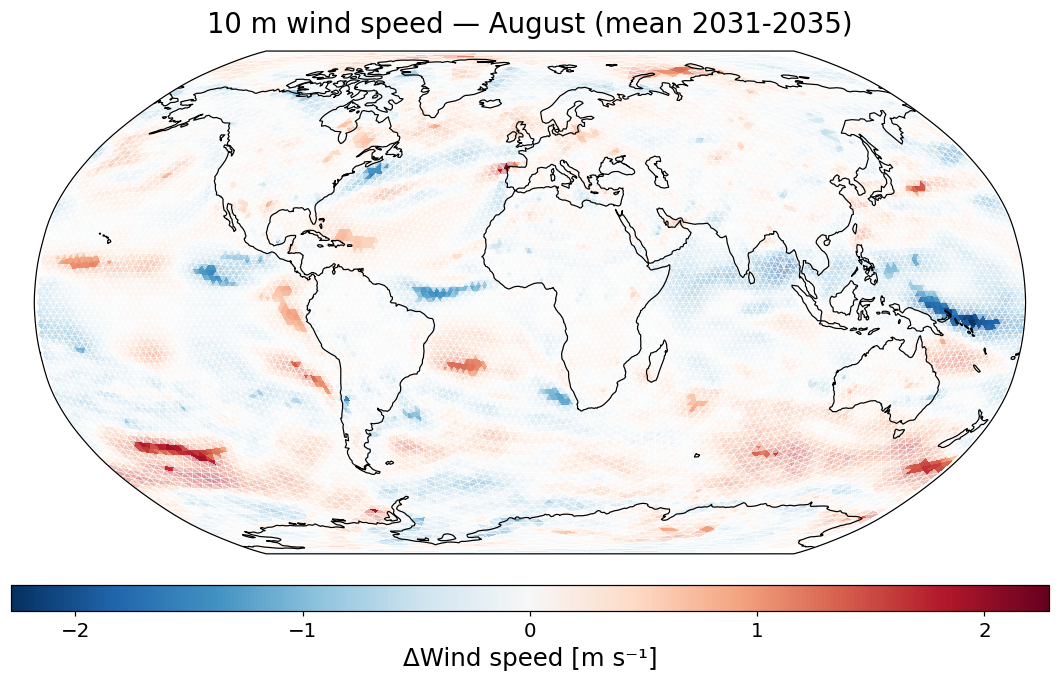

In [10]:
VAR   = "sfcwind"
MONTH = 8        # 1 = Jan … 12 = Dec

sim_m  = data_win[VAR].sel(time=data_win.time.dt.month == MONTH).mean("time")
ctrl_m = slabctr_win[VAR].sel(time=slabctr_win.time.dt.month == MONTH).mean("time")
values = (sim_m - ctrl_m).values

ns = ttest_month(data_win[VAR], slabctr_win[VAR], MONTH)

diff_map(
    values,
    title=f"10 m wind speed — {MONTHS[MONTH-1]} (mean {period})",
    cbar_label="ΔWind speed [m s⁻¹]",
    cmap="RdBu_r",
    not_significant=ns,
    savename=f"map_sfcwind_{MONTHS[MONTH-1]}_{period}.png",
)

## Plot 7 — Net surface heat flux difference map

Sensible + latent (turbulent) heat flux. Both are upward-positive in ICON, so their sum is the total turbulent flux out of the surface.

  t-test: 4 vs 4 years
saved map_heatflux_August_2031-2035.png


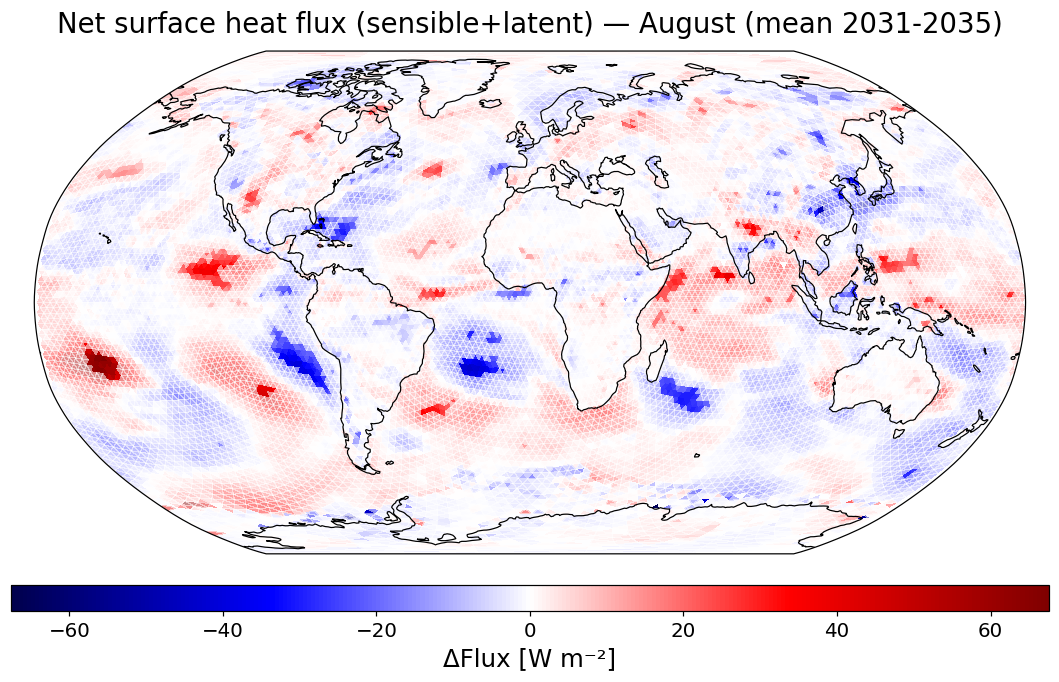

In [11]:
MONTH = 8        # 1 = Jan … 12 = Dec

# Net turbulent surface heat flux = sensible + latent.
def _turb_flux(ds):
    return ds["hfss"] + ds["hfls"]

sim_m  = _turb_flux(data_win).sel(time=data_win.time.dt.month == MONTH).mean("time")
ctrl_m = _turb_flux(slabctr_win).sel(time=slabctr_win.time.dt.month == MONTH).mean("time")
values = (sim_m - ctrl_m).values

# t-test on the summed field
import numpy as _np
_r = _turb_flux(data_win).sel(time=data_win.time.dt.month == MONTH).values
_c = _turb_flux(slabctr_win).sel(time=slabctr_win.time.dt.month == MONTH).values
from scipy import stats as _stats
_, _p = _stats.ttest_ind(_r, _c, axis=0)
ns = _p >= 0.05
print(f"  t-test: {_r.shape[0]} vs {_c.shape[0]} years")

diff_map(
    values,
    title=f"Net surface heat flux (sensible+latent) — {MONTHS[MONTH-1]} (mean {period})",
    cbar_label="ΔFlux [W m⁻²]",
    cmap="seismic",
    not_significant=ns,
    savename=f"map_heatflux_{MONTHS[MONTH-1]}_{period}.png",
)